In [ ]:
from enum import Enum
from fractions import Fraction
from typing import Any
from music21 import (
    clef,
    chord,
    harmony,
    key,
    metadata,
    meter,
    note,
    scale,
    stream,
    tempo,
    tie,
)
from pydantic import BaseModel, computed_field, ConfigDict, Field


class AcceptableKeys(Enum):
    C_MAJOR = "C"
    A_MINOR = "Am"
    G_MAJOR = "G"
    E_MINOR = "Em"
    D_MAJOR = "D"
    B_MINOR = "Bm"
    A_MAJOR = "A"
    FS_MINOR = "F#m"
    E_MAJOR = "E"
    CS_MINOR = "C#m"
    B_MAJOR = "B"
    GS_MINOR = "G#m"
    FS_MAJOR = "F#"
    DS_MINOR = "D#m"
    CS_MAJOR = "C#"
    AS_MINOR = "A#m"
    F_MAJOR = "F"
    D_MINOR = "Dm"
    BF_MAJOR = "Bb"
    G_MINOR = "Gm"
    EF_MAJOR = "Eb"
    C_MINOR = "Cm"
    AF_MAJOR = "Ab"
    F_MINOR = "Fm"
    DF_MAJOR = "Db"
    BF_MINOR = "Bbm"
    GF_MAJOR = "Gb"
    EF_MINOR = "Ebm"
    CF_MAJOR = "Cb"
    AF_MINOR = "Abm"


class AcceptableTimeSigs(Enum):
    TWO_FOUR = "2/4"
    THREE_FOUR = "3/4"
    FOUR_FOUR = "4/4"
    FIVE_FOUR = "5/4"
    SIX_FOUR = "6/4"
    THREE_EIGHT = "3/8"
    FOUR_EIGHT = "4/8"
    FIVE_EIGHT = "5/8"
    SIX_EIGHT = "6/8"
    SEVEN_EIGHT = "7/8"
    NINE_EIGHT = "9/8"
    TWELVE_EIGHT = "12/8"
    TWO_TWO = "2/2"
    THREE_TWO = "3/2"


class BaseSong(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)

    KEYS_MAP: dict[str, int] = {
        "C": 0,
        "Am": 0,
        "G": 1,
        "Em": 1,
        "D": 2,
        "Bm": 2,
        "A": 3,
        "F#m": 3,
        "E": 4,
        "C#m": 4,
        "B": 5,
        "G#m": 5,
        "F#": 6,
        "D#m": 6,
        "C#": 7,
        "A#m": 7,
        "F": -1,
        "Dm": -1,
        "Bb": -2,
        "Gm": -2,
        "Eb": -3,
        "Cm": -3,
        "Ab": -4,
        "Fm": -4,
        "Db": -5,
        "Bbm": -5,
        "Gb": -6,
        "Ebm": -6,
        "Cb": -7,
        "Abm": -7,
    }

    song_key_str: AcceptableKeys = Field(default_factory=lambda: AcceptableKeys.C_MAJOR)
    song_sig_str: AcceptableTimeSigs = Field(
        default_factory=lambda: AcceptableTimeSigs.FOUR_FOUR
    )

    song_key: key.KeySignature = key.KeySignature(0)
    song_sig: meter.TimeSignature = meter.TimeSignature("4/4")

    song: stream.Score = Field(default_factory=lambda: stream.Score())
    part: stream.Part = Field(default_factory=lambda: stream.Part())

    chords: dict[int, list[harmony.ChordSymbol]] = Field(
        default_factory=lambda: {
            0: [harmony.ChordSymbol("Dm7")],
            1: [harmony.ChordSymbol("G13")],
            2: [harmony.ChordSymbol("Cmaj7")],
            3: [harmony.ChordSymbol("A7")],
        }
    )

    def model_post_init(self, context: Any) -> None:
        measures: list[stream.Measure] = []

        for idx, ch in self.chords.items():
            m = stream.Measure()
            if idx == 0:
                m.append(self.song_key)
                m.append(self.song_sig)
            for c in ch:
                m.append(c)
            m.append(note.Note("C4", quarterLength=4))
            measures.append(m)

        for m in measures:
            self.part.append(m)

        self.song.append(self.part)

    def swingify(self, original_stream: stream.Score, swing_ratio=2) -> stream.Score:
        long_dur = Fraction(swing_ratio, swing_ratio + 1)
        short_dur = Fraction(1, swing_ratio + 1)

        for n in original_stream.recurse().notes:
            if n.quarterLength == 0.5:
                beat_pos = n.offset % 1.0

                if beat_pos == 0.0:
                    n.quarterLength = long_dur
                elif beat_pos == 0.5:
                    n.offset = float(int(n.offset)) + long_dur
                    n.quarterLength = short_dur

        return original_stream

    def show(self) -> None:
        self.song.show("musicxml.png")

    def play(self, swing: bool = True) -> None:
        swung_song: stream.Score = self.swingify(self.song)
        swung_song.show("midi")

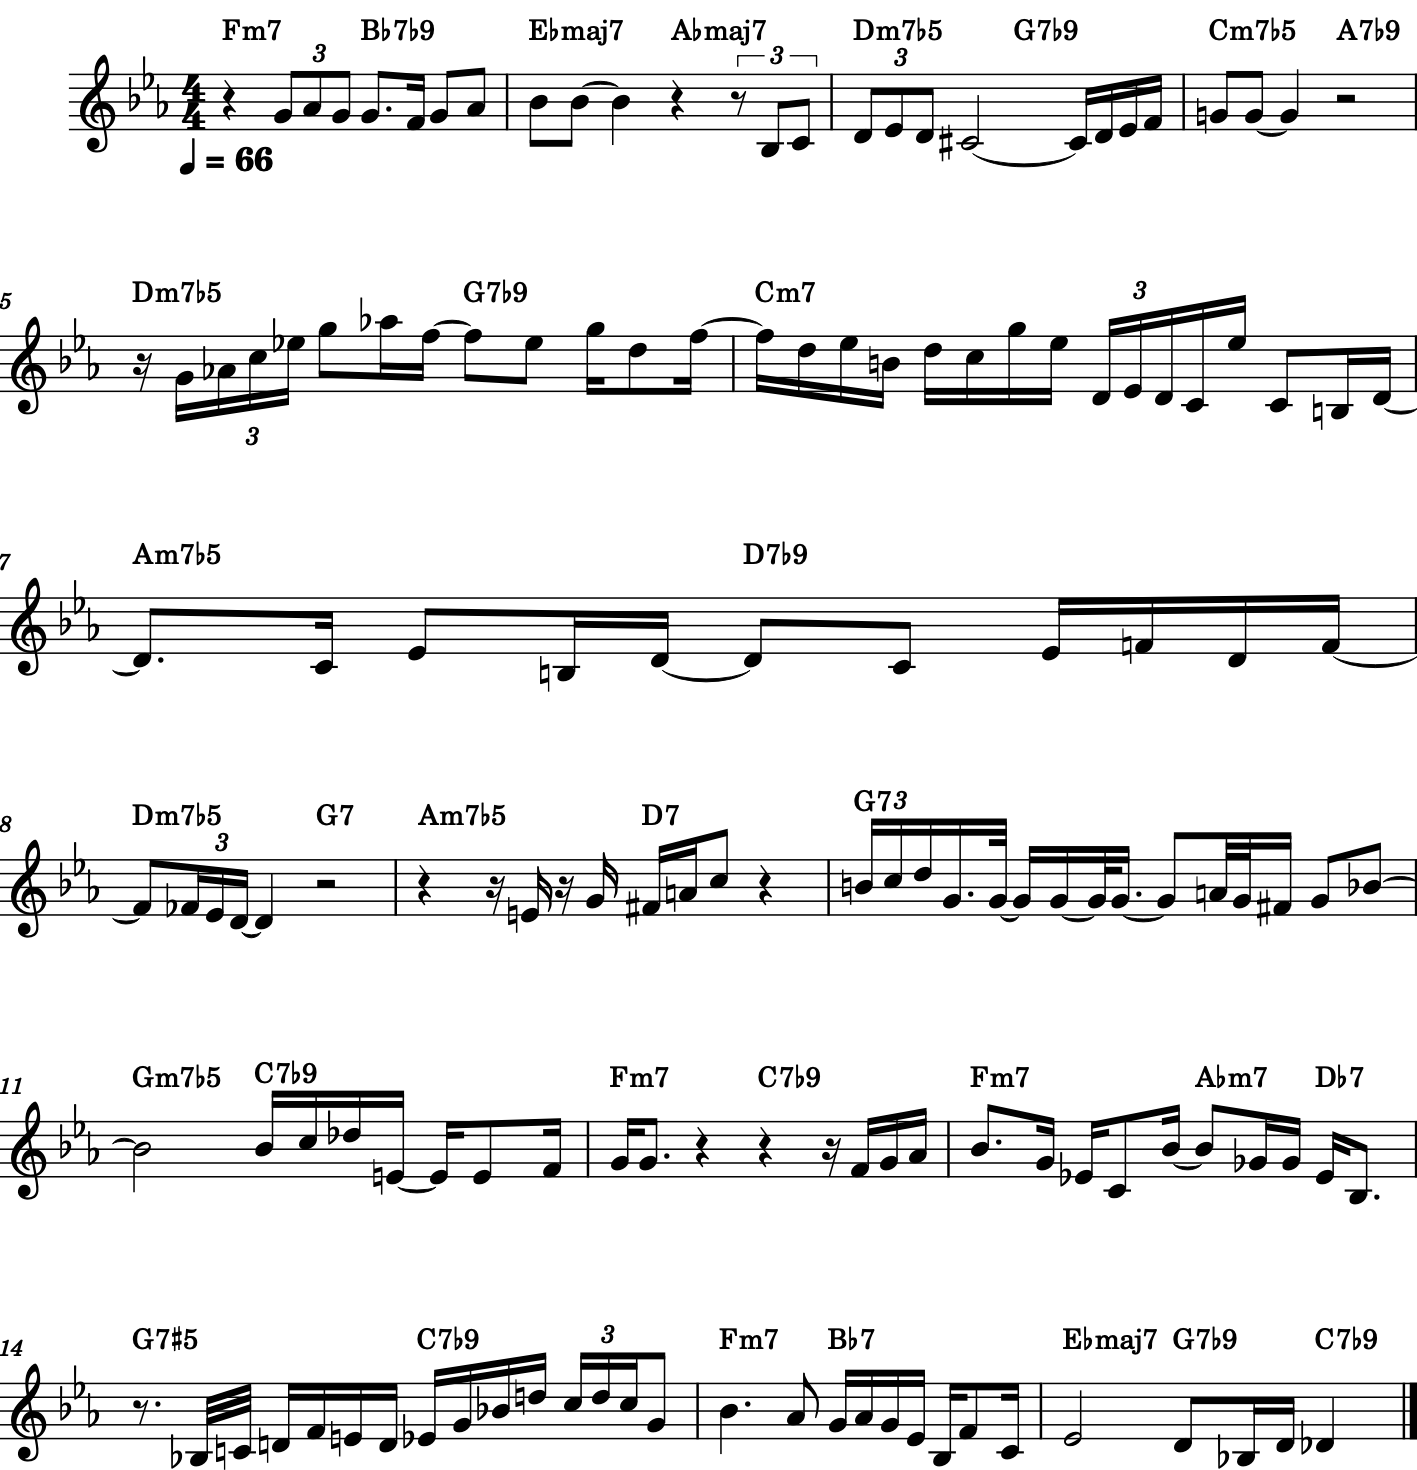

In [ ]:
import platform
from IPython.display import Image
from music21 import (
    bar,
    clef,
    chord,
    environment,
    harmony,
    key,
    layout,
    metadata,
    meter,
    note,
    scale,
    stream,
    tempo,
    tie,
)

e = environment.UserSettings()

if platform.system() == "Darwin":
    p = "/Applications/MuseScore 3.app/Contents/MacOS/mscore"
elif platform.system() == "Windows":
    p = r"C:\Users\Circ8\Documents\Chris\MuseScorePortableLegacy3\MuseScorePortable.exe"

e["musicxmlPath"] = p
e["musescoreDirectPNGPath"] = p

song = stream.Score()
part = stream.Part()

s_key = key.KeySignature(-3)
s_sig = meter.TimeSignature("4/4")
s_tempo = tempo.MetronomeMark(66)

chords: dict[int, list[str]] = {
    0: ["Fm7", "B-7b9"],
    1: ["E-maj7", "A-maj7"],
    2: ["Dm7b5", "G7b9"],
    3: ["Cm7b5", "A7b9"],
    4: ["Dm7b5", "G7b9"],
    5: ["Cm7"],
    6: ["Am7b5", "D7b9"],
    7: ["Dm7b5", "G7"],
    8: ["Am7b5", "D7"],
    9: ["G7"],
    10: ["Gm7b5", "C7b9"],
    11: ["Fm7", "C7b9"],
    12: ["Fm7", "A-m7", "D-7"],
    13: ["G7#5", "C7b9"],
    14: ["Fm7", "B-7"],
    15: ["E-maj7", "G7b9", "C7b9"],
}


def _note(pitch: str, length: float, _tie: str = "None") -> note.Note:
    n = note.Note(pitch, quarterLength=length)
    if _tie != "None":
        n.tie = tie.Tie(_tie)
    return n


def _rest(length: float) -> note.Rest:
    return note.Rest(quarterLength=length)


notes: dict[int, list[note.Note | note.Rest]] = {
    0: [
        _rest(1),
        _note("G4", 0.333333333),
        _note("A-4", 0.333333333),
        _note("G4", 0.333333333),
        _note("G4", 0.75),
        _note("F4", 0.25),
        _note("G4", 0.5),
        _note("A-4", 0.5),
    ],
    1: [
        _note("B-4", 0.5),
        _note("B-4", 0.5, "start"),
        _note("B-4", 1, "stop"),
        _rest(1),
        _rest(0.333333333),
        _note("B-3", 0.333333333),
        _note("C4", 0.333333333),
    ],
    2: [
        _note("D4", 0.333333333),
        _note("E-4", 0.333333333),
        _note("D4", 0.333333333),
        _note("C#4", 2, "start"),
        _note("C#4", 0.25, "stop"),
        _note("D4", 0.25),
        _note("E-4", 0.25),
        _note("F4", 0.25),
    ],
    3: [
        _note("G4", 0.5),
        _note("G4", 0.5, "start"),
        _note("G4", 1, "stop"),
        _rest(2),
    ],
    4: [
        _rest(0.25),
        _note("G4", 0.25),
        _note("A-4", 0.166666666),
        _note("C5", 0.166666666),
        _note("E-5", 0.166666666),
        _note("G5", 0.5),
        _note("A-5", 0.25),
        _note("F5", 0.25, "start"),
        _note("F5", 0.5, "stop"),
        _note("E-5", 0.5),
        _note("G5", 0.25),
        _note("D5", 0.5),
        _note("F5", 0.25, "start"),
    ],
    5: [
        _note("F5", 0.25, "stop"),
        _note("D5", 0.25),
        _note("E-5", 0.25),
        _note("B4", 0.25),
        _note("D5", 0.25),
        _note("C5", 0.25),
        _note("G5", 0.25),
        _note("E-5", 0.25),
        _note("D4", 0.166666666),
        _note("E-4", 0.166666666),
        _note("D4", 0.166666666),
        _note("C4", 0.25),
        _note("E-5", 0.25, "start"),
        _note("C4", 0.5, "stop"),
        _note("B3", 0.25),
        _note("D4", 0.25, "start"),
    ],
    6: [
        _note("D4", 0.75, "stop"),
        _note("C4", 0.25),
        _note("E-4", 0.5),
        _note("B3", 0.25),
        _note("D4", 0.25, "start"),
        _note("D4", 0.5, "stop"),
        _note("C4", 0.5),
        _note("E-4", 0.25),
        _note("F4", 0.25),
        _note("D4", 0.25),
        _note("F4", 0.25, "start"),
    ],
    7: [
        _note("F4", 0.5, "stop"),
        _note("F-4", 0.166666666),
        _note("E-4", 0.166666666),
        _note("D4", 0.166666666, "start"),
        _note("D4", 1, "stop"),
        _rest(2),
    ],
    8: [
        _rest(1),
        _rest(0.25),
        _note("E4", 0.25),
        _rest(0.25),
        _note("G4", 0.25),
        _note("F#4", 0.25),
        _note("A4", 0.25),
        _note("C5", 0.5),
        _rest(1),
    ],
    9: [
        _note("B4", 0.166666666),
        _note("C5", 0.166666666),
        _note("D5", 0.166666666),
        _note("G4", 0.375),
        _note("G4", 0.125, "start"),
        _note("G4", 0.25, "stop"),
        _note("G4", 0.25, "start"),
        _note("G4", 0.125, "stop"),
        _note("G4", 0.375, "start"),
        _note("G4", 0.5, "stop"),
        _note("A4", 0.125),
        _note("G4", 0.125),
        _note("F#4", 0.25),
        _note("G4", 0.5),
        _note("B-4", 0.5, "start"),
    ],
    10: [
        _note("B-4", 2),
        _note("B-4", 0.25, "stop"),
        _note("C5", 0.25),
        _note("D-5", 0.25),
        _note("E4", 0.25, "start"),
        _note("E4", 0.25, "stop"),
        _note("E4", 0.5),
        _note("F4", 0.25),
    ],
    11: [
        _note("G4", 0.25),
        _note("G4", 0.75),
        _rest(1),
        _rest(1),
        _rest(0.25),
        _note("F4", 0.25),
        _note("G4", 0.25),
        _note("A-4", 0.25),
    ],
    12: [
        _note("B-4", 0.75),
        _note("G4", 0.25),
        _note("E-4", 0.25),
        _note("C4", 0.5),
        _note("B-4", 0.25, "start"),
        _note("B-4", 0.5, "stop"),
        _note("G-4", 0.25),
        _note("G-4", 0.25),
        _note("E-4", 0.25),
        _note("B-3", 0.75),
    ],
    13: [
        _rest(0.75),
        _note("B-3", 0.125),
        _note("C4", 0.125),
        _note("D4", 0.25),
        _note("F4", 0.25),
        _note("E4", 0.25),
        _note("D4", 0.25),
        _note("E-4", 0.25),
        _note("G4", 0.25),
        _note("B-4", 0.25),
        _note("D5", 0.25),
        _note("C5", 0.166666666),
        _note("D5", 0.166666666),
        _note("C5", 0.166666666),
        _note("G4", 0.5),
    ],
    14: [
        _note("B-4", 1.5),
        _note("A-4", 0.5),
        _note("G4", 0.25),
        _note("A-4", 0.25),
        _note("G4", 0.25),
        _note("E-4", 0.25),
        _note("B-3", 0.25),
        _note("F4", 0.5),
        _note("C4", 0.25),
    ],
    15: [
        _note("E-4", 2),
        _note("D4", 0.5),
        _note("B-3", 0.25),
        _note("D4", 0.25),
        _note("D-4", 1),
    ],
}


def construct_song(
    _song: stream.Score,
    _part: stream.Part,
    _key: key.KeySignature,
    _sig: meter.TimeSignature,
    _tempo: tempo.MetronomeMark,
    chords: dict[int, list[str]],
    notes: dict[int, list[note.Note | note.Rest]],
):
    for idx in range(len(notes)):
        m = stream.Measure(number=idx + 1)

        if idx == 0:
            m.append(clef.TrebleClef())
            m.append(_key)
            m.append(_sig)

        # if idx in [4, 7, 10, 13]:
        #     m.insert(0, layout.SystemLayout(isNew=True))

        chord_list = chords.get(idx, [])
        if len(chord_list) == 2:
            m.insert(0.0, harmony.ChordSymbol(chord_list[0]))
            m.insert(2.0, harmony.ChordSymbol(chord_list[1]))
        elif len(chord_list) == 3:
            m.insert(0.0, harmony.ChordSymbol(chord_list[0]))
            m.insert(2.0, harmony.ChordSymbol(chord_list[1]))
            m.insert(3.0, harmony.ChordSymbol(chord_list[2]))
        else:
            m.insert(0.0, harmony.ChordSymbol(chord_list[0]))

        curr_offset = 0.0
        for el in notes[idx]:
            m.insert(curr_offset, el)
            curr_offset += el.quarterLength

        if idx == 0:
            m.insert(0.0, _tempo)

        if idx == len(notes) - 1:
            m.rightBarline = bar.Barline("final")

        _part.append(m)

    _song.append(_part)
    return _song


song = construct_song(song, part, s_key, s_sig, s_tempo, chords, notes)

Image(song.write("musicxml.png"))

In [3]:
song.show("midi")

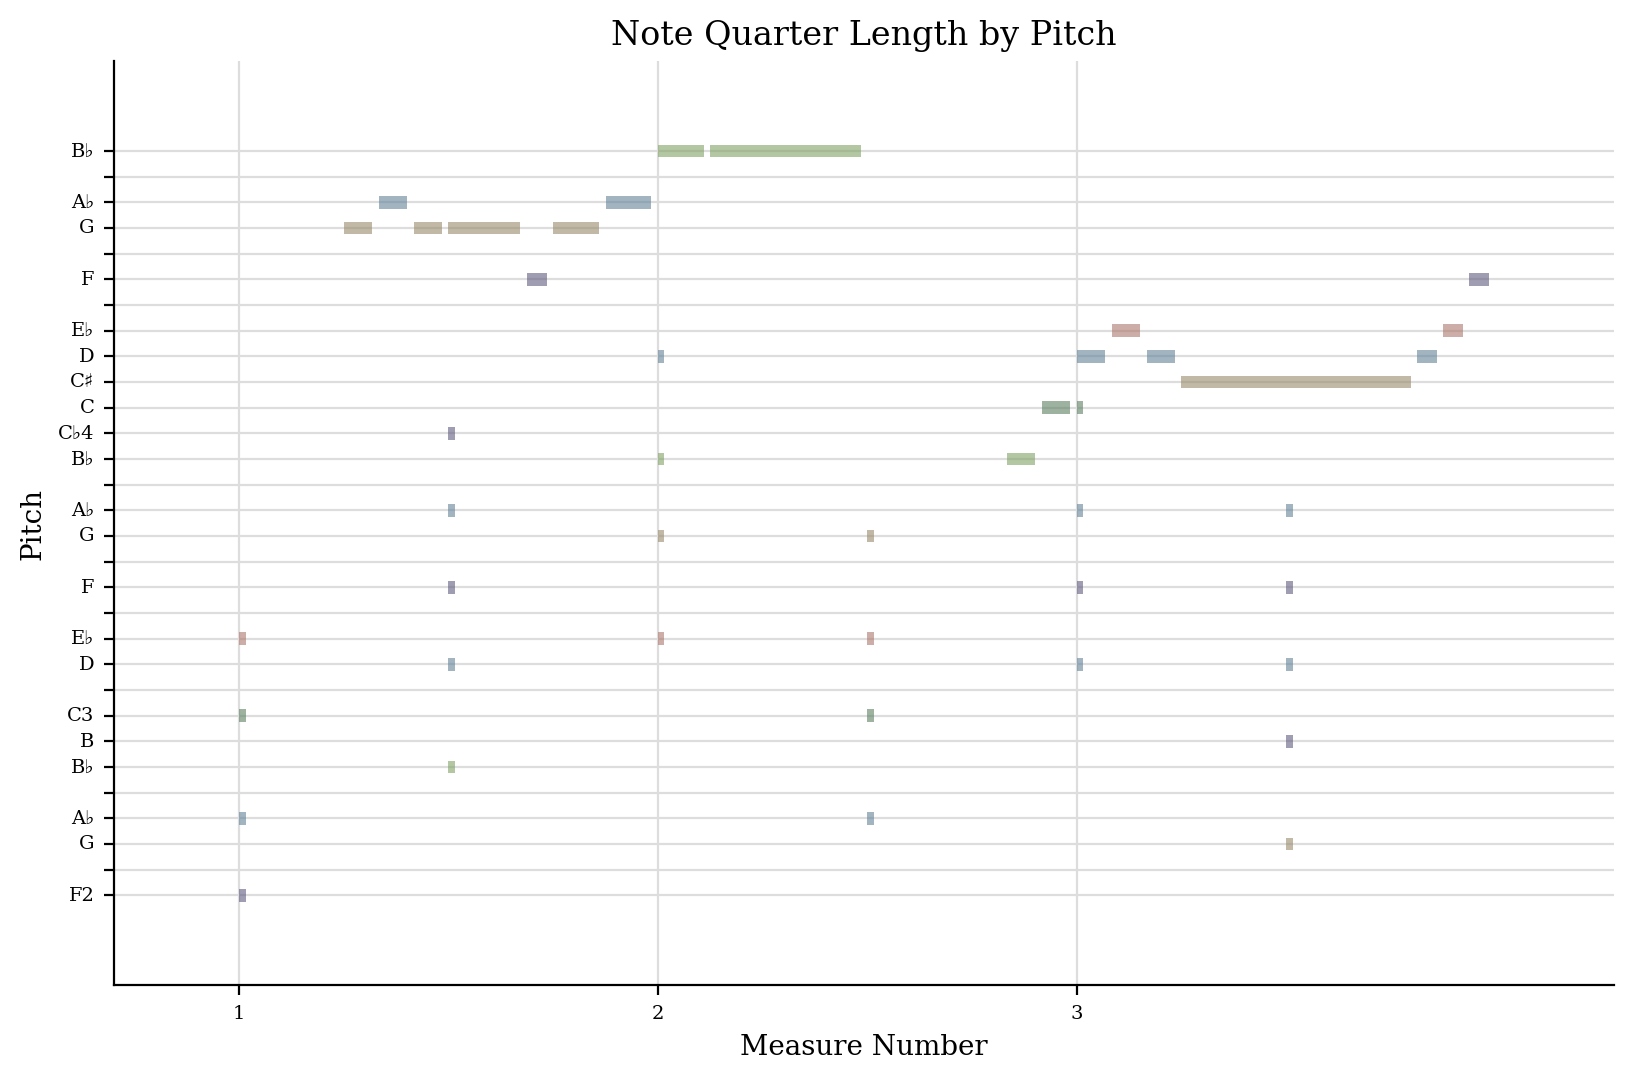

In [4]:
voice = song.parts[0]
voice.measures(1, 3).plot()

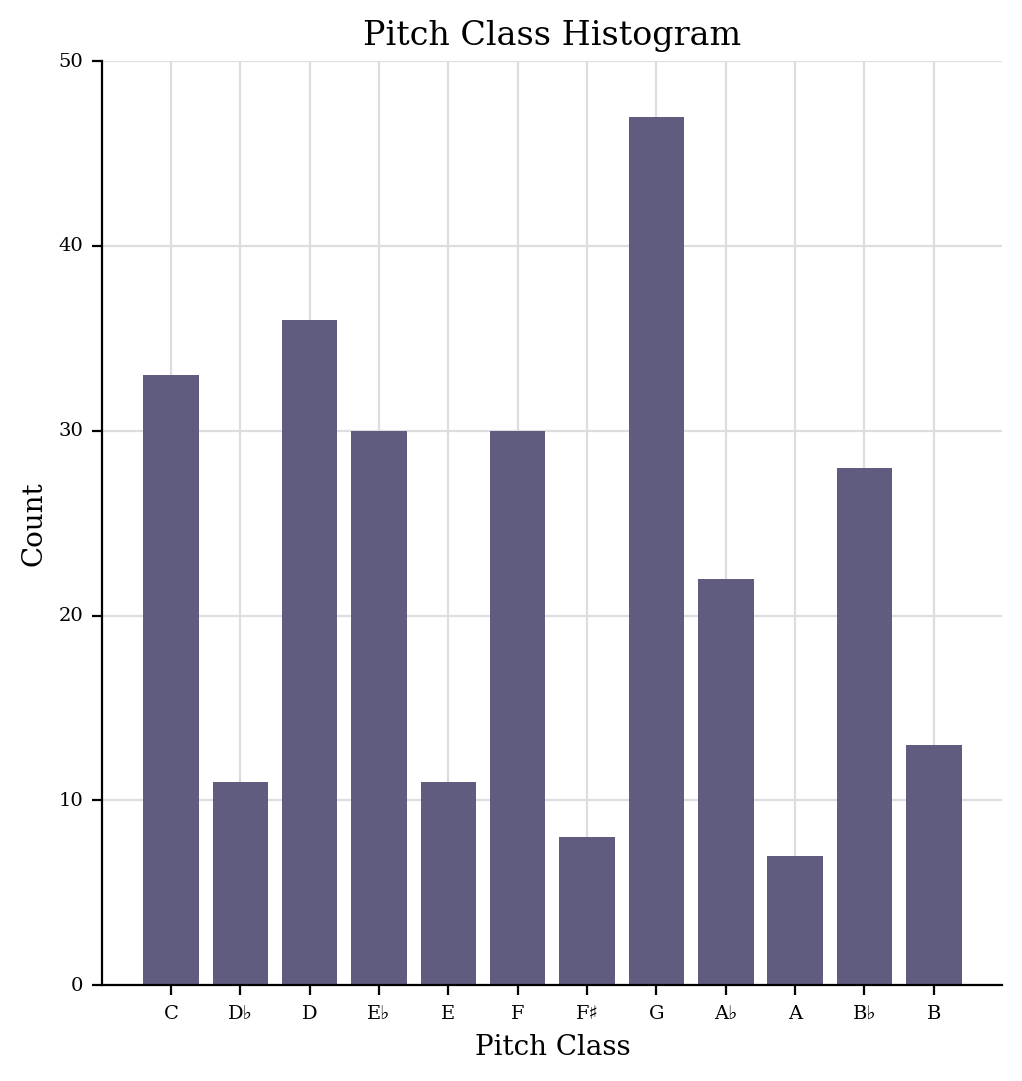

In [5]:
song.plot("histogram", "pitchClass")

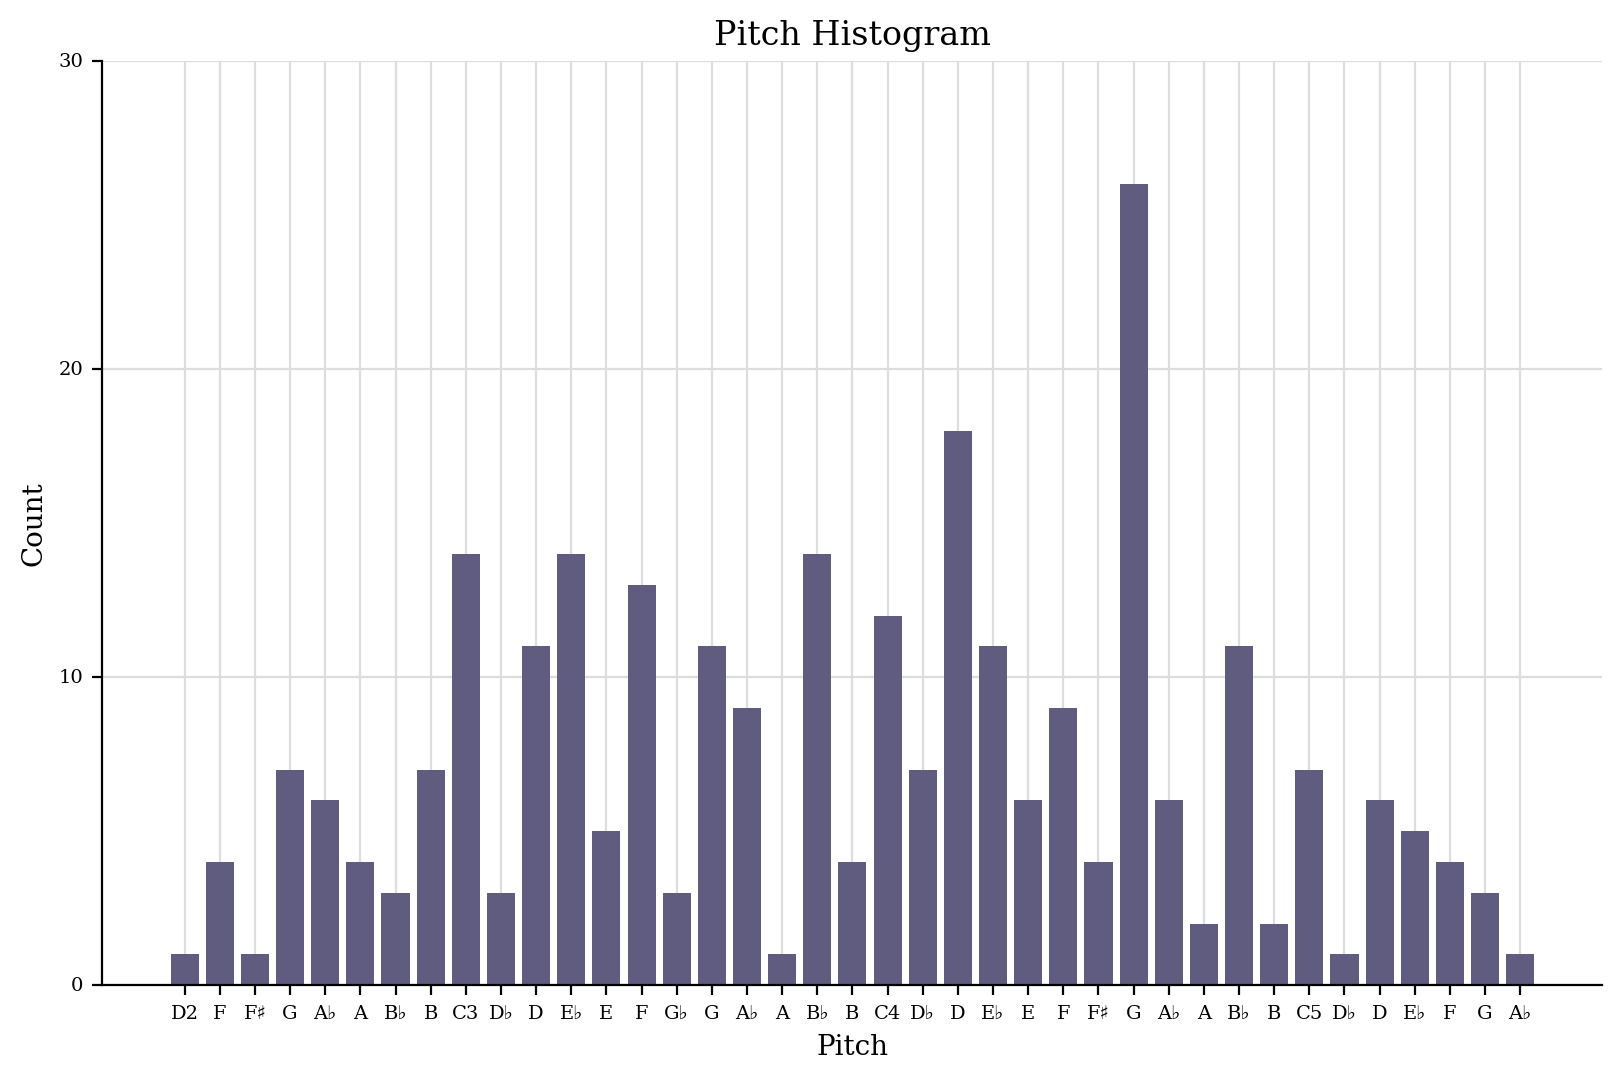

In [6]:
song.plot("histogram", "pitch")

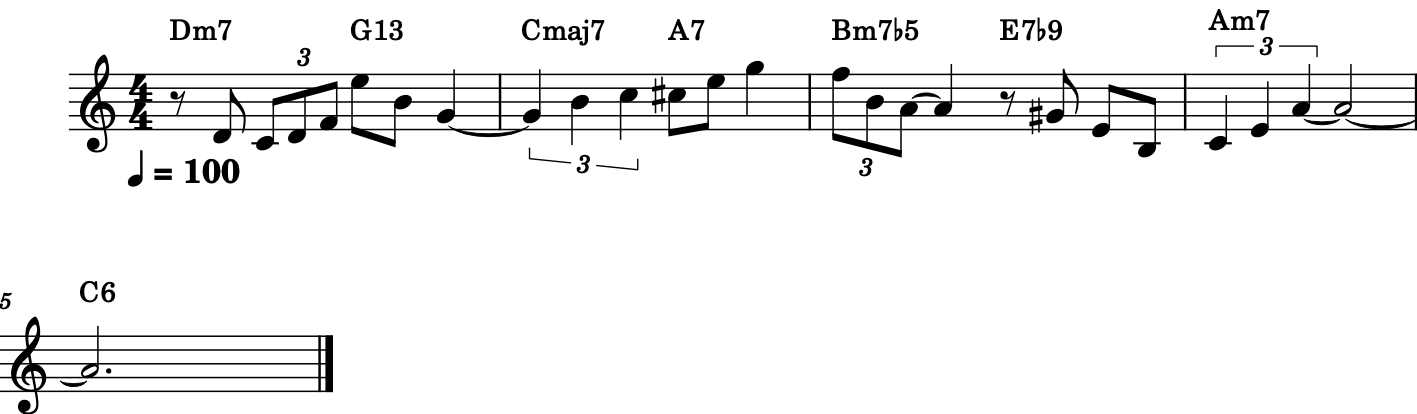

In [ ]:
chords: dict[int, list[str]] = {
    0: ["Dm7", "G13"],
    1: ["Cmaj7", "A7"],
    2: ["Bm7b5", "E7b9"],
    3: ["Am7"],
    4: ["C6"],
}

notes: dict[int, list[note.Note | note.Rest]] = {
    0: [
        _rest(0.5),
        _note("D4", 0.5),
        _note("C4", 0.333333333),
        _note("D4", 0.333333333),
        _note("F4", 0.333333333),
        _note("E5", 0.5),
        _note("B4", 0.5),
        _note("G4", 1.0, "start"),
    ],
    1: [
        _note("G4", 0.666666666, "stop"),
        _note("B4", 0.666666666),
        _note("C5", 0.666666666),
        _note("C#5", 0.5),
        _note("E5", 0.5),
        _note("G5", 1),
    ],
    2: [
        _note("F5", 0.333333333),
        _note("B4", 0.333333333),
        _note("A4", 0.333333333, "start"),
        _note("A4", 1, "stop"),
        _rest(0.5),
        _note("G#4", 0.5),
        _note("E4", 0.5),
        _note("B3", 0.5),
    ],
    3: [
        _note("C4", 0.666666666),
        _note("E4", 0.666666666),
        _note("A4", 0.666666666, "start"),
        _note("A4", 2.0, "continue"),
    ],
    4: [
        _note("A4", 3.0, "stop"),
    ],
}

song: stream.Score = stream.Score()
part: stream.Part = stream.Part()
song_key: key.KeySignature = key.KeySignature(0)
song_sig: meter.TimeSignature = meter.TimeSignature("4/4")
song_tempo: tempo.MetronomeMark = tempo.MetronomeMark(100)

song: stream.Score = construct_song(
    song, part, song_key, song_sig, song_tempo, chords, notes
)

Image(song.write("musicxml.png"))

In [14]:
song.show("midi")

need to implement:

 - barlines
 - repeats
 - codas
 - segnos
 - 

In [ ]:
from enum import StrEnum
from music21 import harmony
from pydantic import BaseModel, Field, model_validator
from typing_extensions import Self


class AcceptableKeys(StrEnum):
    C_MAJOR = "C"
    A_MINOR = "Am"
    G_MAJOR = "G"
    E_MINOR = "Em"
    D_MAJOR = "D"
    B_MINOR = "Bm"
    A_MAJOR = "A"
    FS_MINOR = "F#m"
    E_MAJOR = "E"
    CS_MINOR = "C#m"
    B_MAJOR = "B"
    GS_MINOR = "G#m"
    FS_MAJOR = "F#"
    DS_MINOR = "D#m"
    CS_MAJOR = "C#"
    AS_MINOR = "A#m"
    F_MAJOR = "F"
    D_MINOR = "Dm"
    BF_MAJOR = "Bb"
    G_MINOR = "Gm"
    EF_MAJOR = "Eb"
    C_MINOR = "Cm"
    AF_MAJOR = "Ab"
    F_MINOR = "Fm"
    DF_MAJOR = "Db"
    BF_MINOR = "Bbm"
    GF_MAJOR = "Gb"
    EF_MINOR = "Ebm"
    CF_MAJOR = "Cb"
    AF_MINOR = "Abm"


class AcceptableTimeSigs(StrEnum):
    TWO_FOUR = "2/4"
    THREE_FOUR = "3/4"
    FOUR_FOUR = "4/4"
    FIVE_FOUR = "5/4"
    SIX_FOUR = "6/4"
    THREE_EIGHT = "3/8"
    FOUR_EIGHT = "4/8"
    FIVE_EIGHT = "5/8"
    SIX_EIGHT = "6/8"
    SEVEN_EIGHT = "7/8"
    NINE_EIGHT = "9/8"
    TWELVE_EIGHT = "12/8"
    TWO_TWO = "2/2"
    THREE_TWO = "3/2"


class ChordProgression(BaseModel):
    name: str
    song_key: AcceptableKeys
    song_time_signature: AcceptableTimeSigs
    num_measures: int = 4
    chords: list[list[str]] = Field(
        default_factory=lambda: [
            ["Dm7"],
            ["G13"],
            ["Cmaj7"],
            ["Cmaj7"],
        ]
    )

    @model_validator(mode="after")
    def validate_key_sig_chords(self) -> Self:
        if len(self.chords) != self.num_measures:
            raise ValueError(
                f"Amount of measures must be {self.num_measures}, got {len(self.chords)}"
            )
        if self.song_key not in AcceptableKeys:
            raise ValueError(f"Key is not an acceptable key, got {self.song_key}")
        if self.song_time_signature not in AcceptableTimeSigs:
            raise ValueError(
                f"Time signature is not an acceptable time signature, got {self.song_time_signature}"
            )
        return self
    
    def generate_improvisation_notes(self, style: str = "Swing") -> list[list[dict[str, list[str]]]]:
        return_notes: list[list[dict[str, list[str]]]] = [[]] * self.num_measures
        for measure_idx, chord_measure in enumerate(self.chords):
            chord_lengths: list[float] = [1.0]
            if len(chord_measure) == 2:
                chord_lengths = [0.5, 0.5]
            elif len(chord_measure) == 3:
                chord_lengths = [0.5, 0.25, 0.25]
            elif len(chord_measure) == 4:
                chord_lengths = [0.25, 0.25, 0.25, 0.25]
            
            beat_info: dict[str, list[str]] = {}
            
            for chord_beat, chord_str in enumerate(chord_measure):
                chord_name_length: str = f"{chord_str}_{chord_lengths[chord_beat]}"
                chord_object: harmony.ChordSymbol = harmony.ChordSymbol(chord_str)
                chord_notes: list[str] = [k.name for k in chord_object.pitches]

                beat_info = {
                    chord_name_length: chord_notes
                }
            return_notes[measure_idx].append(beat_info)

        return return_notes
    
    def generate_improvisation_measures(self, style: str = "Swing") -> list[note.Note]:
        return_notes: list[note.Note] = []
        improvisation_notes: list[list[dict[str, list[str]]]] = self.generate_improvisation_notes()

        for i in improvisation_notes:
            print(i)

        return return_notes

In [25]:
test = ChordProgression(
    name="Test",
    song_key=AcceptableKeys.C_MAJOR,
    song_time_signature=AcceptableTimeSigs.FOUR_FOUR,
)

test.generate_improvisation_measures()

[{'Dm7_1.0': ['D', 'F', 'A', 'C']}, {'G13_1.0': ['G', 'B', 'D', 'F', 'A', 'C', 'E']}, {'Cmaj7_1.0': ['C', 'E', 'G', 'B']}, {'Cmaj7_1.0': ['C', 'E', 'G', 'B']}]
[{'Dm7_1.0': ['D', 'F', 'A', 'C']}, {'G13_1.0': ['G', 'B', 'D', 'F', 'A', 'C', 'E']}, {'Cmaj7_1.0': ['C', 'E', 'G', 'B']}, {'Cmaj7_1.0': ['C', 'E', 'G', 'B']}]
[{'Dm7_1.0': ['D', 'F', 'A', 'C']}, {'G13_1.0': ['G', 'B', 'D', 'F', 'A', 'C', 'E']}, {'Cmaj7_1.0': ['C', 'E', 'G', 'B']}, {'Cmaj7_1.0': ['C', 'E', 'G', 'B']}]
[{'Dm7_1.0': ['D', 'F', 'A', 'C']}, {'G13_1.0': ['G', 'B', 'D', 'F', 'A', 'C', 'E']}, {'Cmaj7_1.0': ['C', 'E', 'G', 'B']}, {'Cmaj7_1.0': ['C', 'E', 'G', 'B']}]


[]

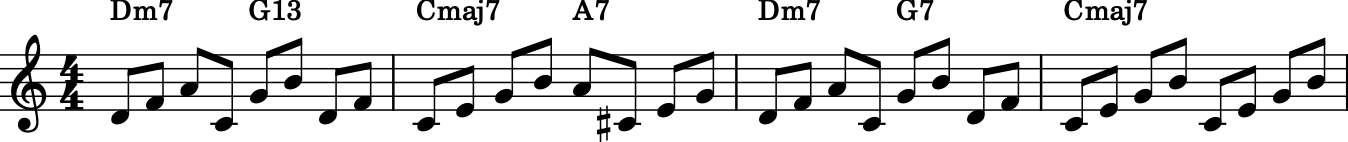

In [2]:
import music21
import platform
from IPython.display import Image

us = music21.environment.UserSettings()

if platform.system() == "Darwin":
    p = "/Applications/MuseScore 3.app/Contents/MacOS/mscore"
elif platform.system() == "Windows":
    p = r"C:\Users\Circ8\Documents\Chris\MuseScorePortableLegacy3\MuseScorePortable.exe"

us["musicxmlPath"] = p
us["musescoreDirectPNGPath"] = p


chord_strs: list[list[str]] = [
    ["Dm7", "G13"],
    ["Cmaj7", "A7"],
    ["Dm7", "G7"],
    ["Cmaj7"],
]

improv_notes: list[list[str]] = []
for measure_idx, chord_list in enumerate(chord_strs):
    measure_notes = []
    for chord_str in chord_list:
        chord_obj: music21.harmony.ChordSymbol = music21.harmony.ChordSymbol(chord_str)
        chord_tones: list[str] = [f"{p.name}_0.5" for p in chord_obj.pitches]
        chord_tones = chord_tones[:4]
        
        measure_notes.extend(chord_tones)
        if len(chord_list) == 1:
            measure_notes.extend(chord_tones)
    improv_notes.append(measure_notes)

s = music21.stream.Score()
p = music21.stream.Part()

for m_idx, m_notes in enumerate(improv_notes):
    cs = chord_strs[m_idx]
    m = music21.stream.Measure()
    if m_idx == 0:
        m.insert(0.0, music21.key.KeySignature(0))
        m.insert(0.0, music21.meter.TimeSignature("4/4"))
    for n_idx, ns in enumerate(m_notes):
        n = music21.note.Note(ns.split("_")[0], quarterLength=float(ns.split("_")[1]))
        m.append(n)
    if len(cs) == 1:
        c = music21.harmony.ChordSymbol(cs[0])
        m.insert(0.0, c)
    elif len(cs) == 2:
        c1 = music21.harmony.ChordSymbol(cs[0])
        c2 = music21.harmony.ChordSymbol(cs[1])
        m.insert(0.0, c1)
        m.insert(2.0, c2)
    p.append(m)
s.append(p)

Image(s.write("musicxml.png"))

In [3]:
from fractions import Fraction


def swingify(original_stream: music21.stream.Score, swing_ratio: int = 2) -> music21.stream.Score:
    long_dur = Fraction(swing_ratio, swing_ratio + 1)
    short_dur = Fraction(1, swing_ratio + 1)

    for n in original_stream.recurse().notes:
        if n.quarterLength == 0.5:
            beat_pos = n.offset % 1.0

            if beat_pos == 0.0:
                n.quarterLength = long_dur
            elif beat_pos == 0.5:
                n.offset = float(int(n.offset)) + long_dur
                n.quarterLength = short_dur
    return original_stream

ss = swingify(s)
ss.show("midi")